[✓] Base pipeline dependencies imported smoothly.

--- DATASET FIRST 5 ROWS ---
   X  Y month  day  FFMC   DMC     DC  ISI  temp  RH  wind  rain  area
0  7  5   mar  fri  86.2  26.2   94.3  5.1   8.2  51   6.7   0.0   0.0
1  7  4   oct  tue  90.6  35.4  669.1  6.7  18.0  33   0.9   0.0   0.0
2  7  4   oct  sat  90.6  43.7  686.9  6.7  14.6  33   1.3   0.0   0.0
3  8  6   mar  fri  91.7  33.3   77.5  9.0   8.3  97   4.0   0.2   0.0
4  8  6   mar  sun  89.3  51.3  102.2  9.6  11.4  99   1.8   0.0   0.0

[i] Structural Shape Matrix Dimensions: 517 Rows, 13 Columns
[i] Feature Set Labels: ['X', 'Y', 'month', 'day', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'area']

--- ARCHITECTURAL DATA TYPES & COMPOSITION (info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   mo

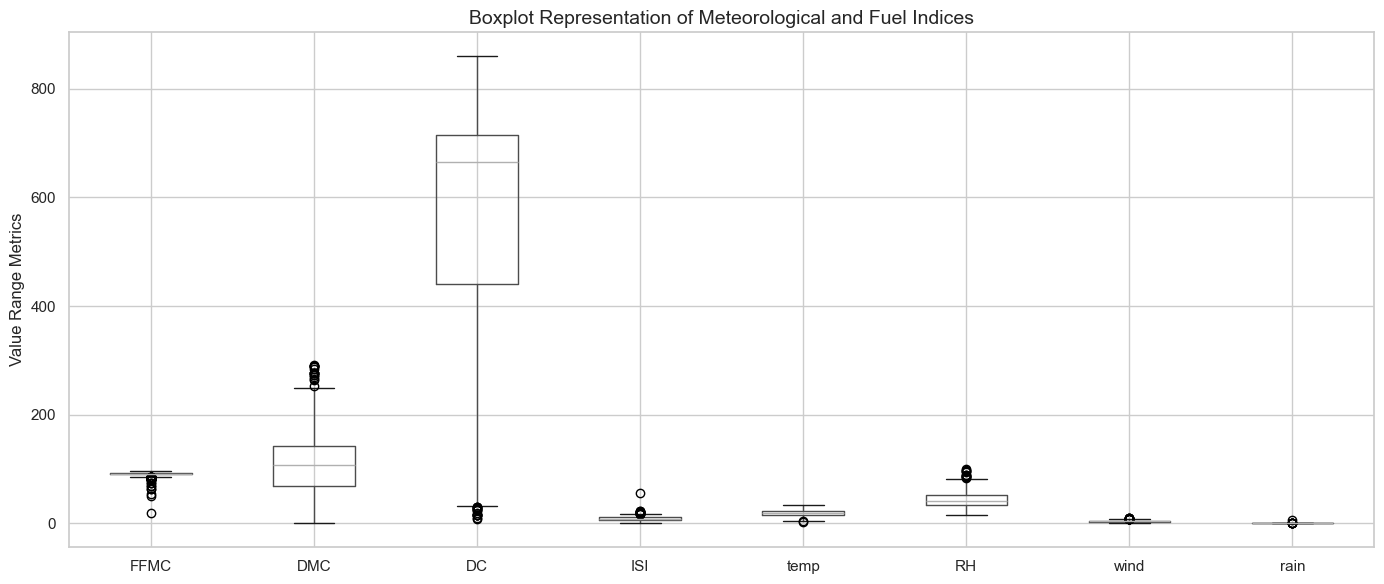

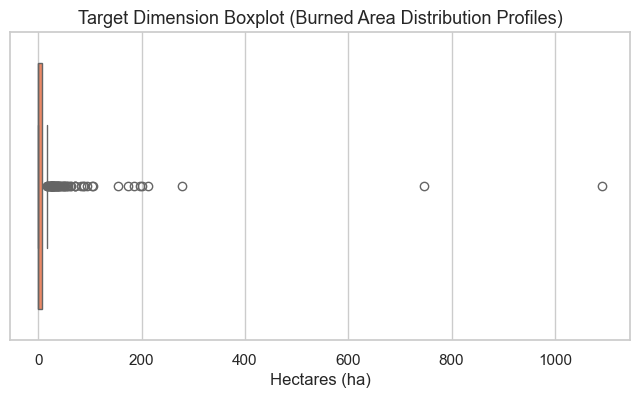

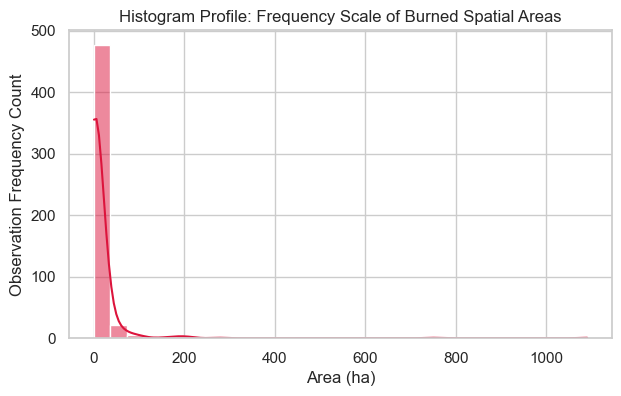

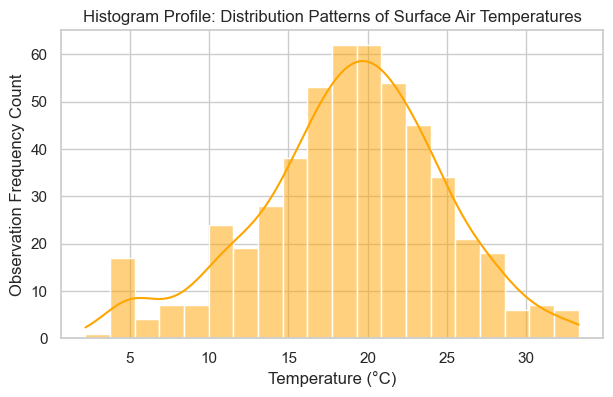

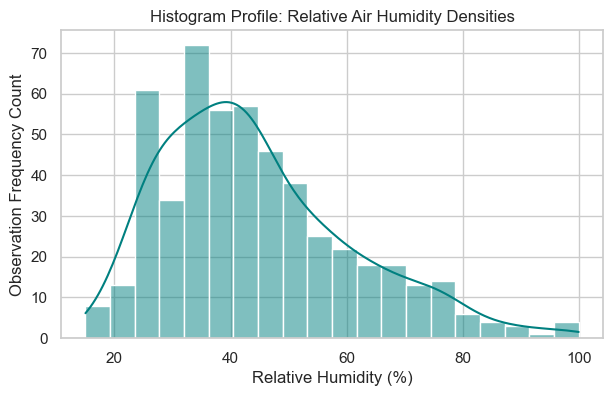

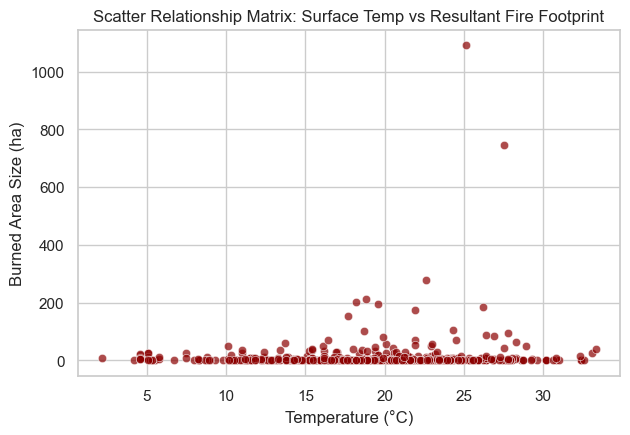

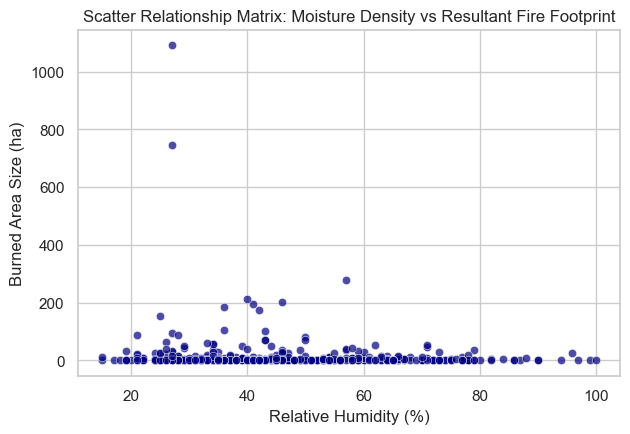

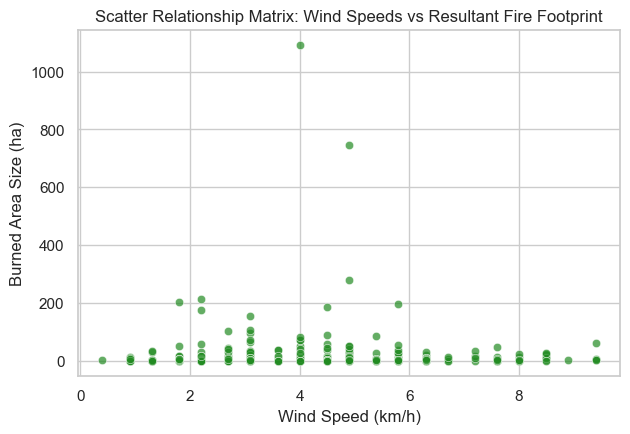

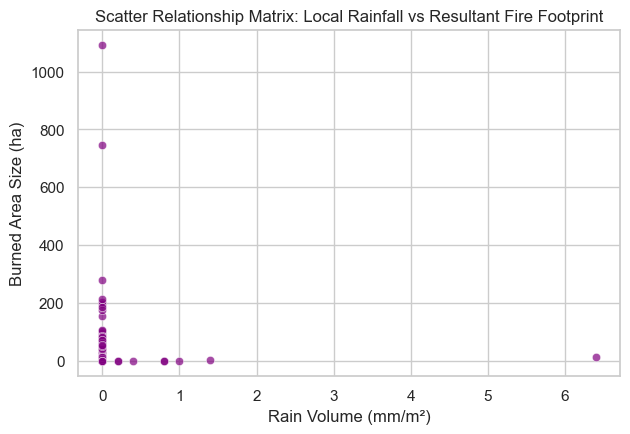

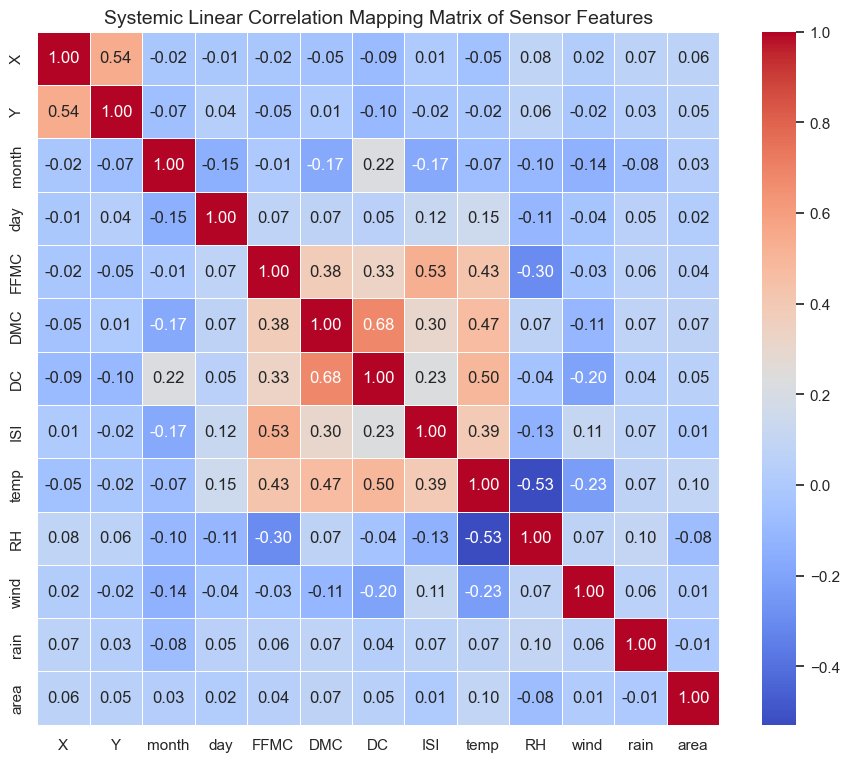

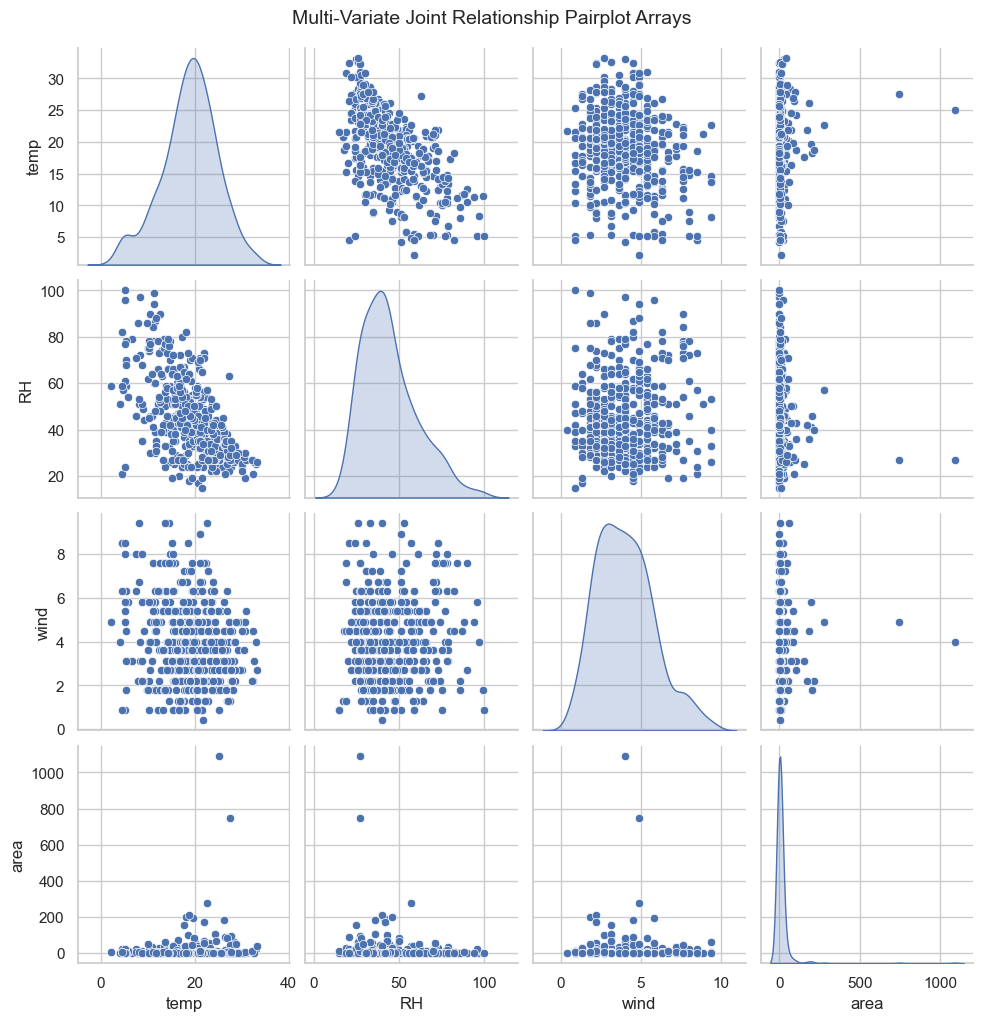


--- CLASS CONCENTRATION LABELS SUMMARY ---
Risk
Low       271
Medium    191
High       51
Name: count, dtype: int64


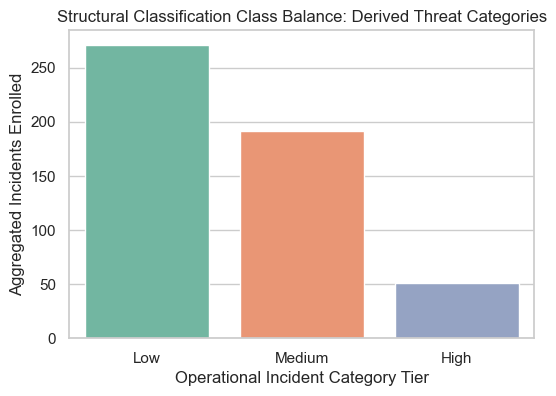


=== SYSTEM REGRESSION PERFORMANCE SCOREBOARD ===
         Model Architecture       MAE      RMSE   R2 Score
          Linear Regression 15.913845 22.269202  -0.287763
    Decision Tree Regressor 27.462448 89.042532 -19.588358
    Random Forest Regressor 18.477518 34.886612  -2.160416
Gradient Boosting Regressor 28.022434 78.555388 -15.024285

[✓] Retained Model Solution for Deployment Target: Linear Regression

>>> Technical Classification Report Profile [Logistic Regression] <<<
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         7
         Low       0.55      0.90      0.68        58
      Medium       0.33      0.08      0.13        38

    accuracy                           0.53       103
   macro avg       0.30      0.33      0.27       103
weighted avg       0.43      0.53      0.43       103


>>> Technical Classification Report Profile [Decision Tree Classifier] <<<
              precision    recall  f1-score   support

  

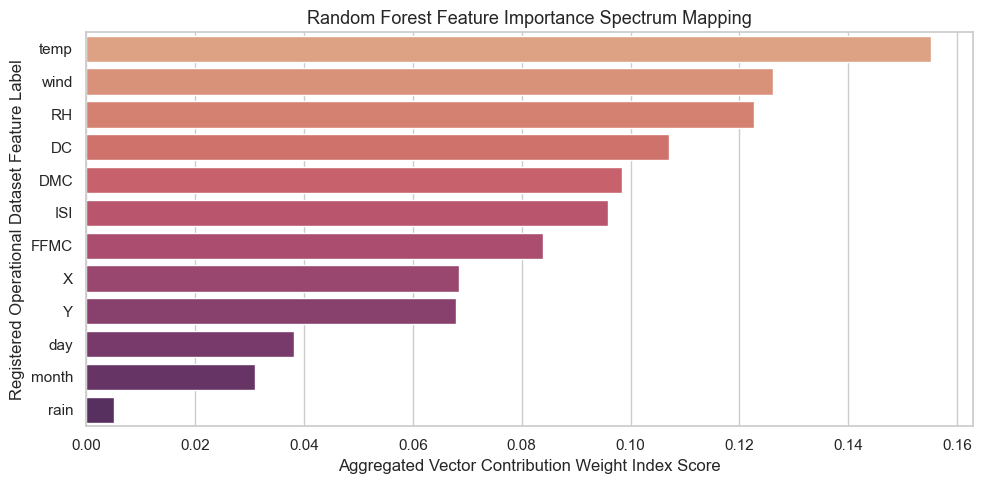


--- CORE INFORMATION UTILITY ORDER PROFILE ---
Predictive Feature Label  Calculated Relative Weight Importance
                    temp                               0.155131
                    wind                               0.126164
                      RH                               0.122637
                      DC                               0.107108
                     DMC                               0.098451
                     ISI                               0.095939
                    FFMC                               0.083902
                       X                               0.068524
                       Y                               0.067888
                     day                               0.038107
                   month                               0.031059
                    rain                               0.005089
+======================================================================+
|                  INCIDENT RISK INTELLIGENCE R

In [2]:
# ==============================================================================
# FOREST FIRE RISK AND BURNED AREA ESTIMATOR FRAMEWORK
# Academic Submission Profile: Anisha Katariya | Roll Number: IT-2K24-12
# Framework Target: Complete Executable Linear Scripting Pipeline
# ==============================================================================

# ------------------------------------------------------------------------------
# 2. IMPORT LIBRARIES
# ------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, 
                             accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, classification_report)
import joblib
import warnings

# Configure visual canvas defaults
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
warnings.filterwarnings('ignore')

print("[✓] Base pipeline dependencies imported smoothly.")

# ------------------------------------------------------------------------------
# 3. LOAD DATASET & BASIC INSPECTION
# ------------------------------------------------------------------------------
# Ingest the target comma-separated document object matrix
# Ingest the target comma-separated document object matrix
df = pd.read_csv('[SubtitleTools.com] forestfires.csv')

print("\n--- DATASET FIRST 5 ROWS ---")
print(df.head())

print(f"\n[i] Structural Shape Matrix Dimensions: {df.shape[0]} Rows, {df.shape[1]} Columns")
print(f"[i] Feature Set Labels: {df.columns.tolist()}")

print("\n--- ARCHITECTURAL DATA TYPES & COMPOSITION (info) ---")
df.info()

print("\n--- REVENUE & METEOROLOGICAL MATHEMATICAL EXPRESSIONS (describe) ---")
print(df.describe())

print("\n[i] Missing Value Mapping Vector:")
print(df.isnull().sum())

# Deduplication Processing
duplicate_records_count = df.duplicated().sum()
print(f"\n[i] Identified Duplicate Intersecting Sequences: {duplicate_records_count}")
if duplicate_records_count > 0:
    df.drop_duplicates(inplace=True)
    print("[✓] Redundant data entries extracted and purged successfully.")

# ------------------------------------------------------------------------------
# 4. DATA PREPROCESSING
# ------------------------------------------------------------------------------
# Instantiating categorical encoders for chronological strings
le_month = LabelEncoder()
le_day = LabelEncoder()

df['month'] = le_month.fit_transform(df['month'])
df['day'] = le_day.fit_transform(df['day'])

print("\n[✓] Character dimensions 'month' and 'day' re-mapped to ordinal indices.")

# Boxplot visualization to scan features distribution and anomalies
plt.figure(figsize=(14, 6))
df[['FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']].boxplot()
plt.title("Boxplot Representation of Meteorological and Fuel Indices", fontsize=14)
plt.ylabel("Value Range Metrics")
plt.tight_layout()
plt.show()

# Isolate Target distribution check to view heavy skewness
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['area'], color='coral')
plt.title("Target Dimension Boxplot (Burned Area Distribution Profiles)", fontsize=13)
plt.xlabel("Hectares (ha)")
plt.show()

# ------------------------------------------------------------------------------
# 5. EXPLORATORY DATA ANALYSIS (EDA)
# ------------------------------------------------------------------------------
# Plot 1: Target Log/Linear Spreading
plt.figure(figsize=(7, 4))
sns.histplot(df['area'], bins=30, kde=True, color='crimson')
plt.title('Histogram Profile: Frequency Scale of Burned Spatial Areas', fontsize=12)
plt.xlabel('Area (ha)')
plt.ylabel('Observation Frequency Count')
plt.show()

# Plot 2: Thermodynamic Spreads
plt.figure(figsize=(7, 4))
sns.histplot(df['temp'], bins=20, kde=True, color='orange')
plt.title('Histogram Profile: Distribution Patterns of Surface Air Temperatures', fontsize=12)
plt.xlabel('Temperature (°C)')
plt.ylabel('Observation Frequency Count')
plt.show()

# Plot 3: Hydro-Sensor Quantifications
plt.figure(figsize=(7, 4))
sns.histplot(df['RH'], bins=20, kde=True, color='teal')
plt.title('Histogram Profile: Relative Air Humidity Densities', fontsize=12)
plt.xlabel('Relative Humidity (%)')
plt.ylabel('Observation Frequency Count')
plt.show()

# Plot 4: Scatter Mechanics - Temperature vs Area
plt.figure(figsize=(7, 4.5))
sns.scatterplot(data=df, x='temp', y='area', alpha=0.7, color='darkred')
plt.title('Scatter Relationship Matrix: Surface Temp vs Resultant Fire Footprint', fontsize=12)
plt.xlabel('Temperature (°C)')
plt.ylabel('Burned Area Size (ha)')
plt.show()

# Plot 5: Scatter Mechanics - Humidity vs Area
plt.figure(figsize=(7, 4.5))
sns.scatterplot(data=df, x='RH', y='area', alpha=0.7, color='navy')
plt.title('Scatter Relationship Matrix: Moisture Density vs Resultant Fire Footprint', fontsize=12)
plt.xlabel('Relative Humidity (%)')
plt.ylabel('Burned Area Size (ha)')
plt.show()

# Plot 6: Scatter Mechanics - Atmospheric Velocity vs Area
plt.figure(figsize=(7, 4.5))
sns.scatterplot(data=df, x='wind', y='area', alpha=0.7, color='forestgreen')
plt.title('Scatter Relationship Matrix: Wind Speeds vs Resultant Fire Footprint', fontsize=12)
plt.xlabel('Wind Speed (km/h)')
plt.ylabel('Burned Area Size (ha)')
plt.show()

# Plot 7: Scatter Mechanics - Precipitation Metrics vs Area
plt.figure(figsize=(7, 4.5))
sns.scatterplot(data=df, x='rain', y='area', alpha=0.7, color='purple')
plt.title('Scatter Relationship Matrix: Local Rainfall vs Resultant Fire Footprint', fontsize=12)
plt.xlabel('Rain Volume (mm/m²)')
plt.ylabel('Burned Area Size (ha)')
plt.show()

# Plot 8: Full Line Correlation Matrix
plt.figure(figsize=(11, 9))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, cbar=True)
plt.title('Systemic Linear Correlation Mapping Matrix of Sensor Features', fontsize=14)
plt.show()

# Plot 9: Multi-Dimensional Feature Intersections Pairplot
sns.pairplot(df[['temp', 'RH', 'wind', 'area']], diag_kind='kde', palette='viridis')
plt.suptitle('Multi-Variate Joint Relationship Pairplot Arrays', y=1.02, fontsize=14)
plt.show()

# ------------------------------------------------------------------------------
# 6. FEATURE ENGINEERING
# ------------------------------------------------------------------------------
def evaluate_risk_profile(area_value):
    if area_value < 1.0:
        return 'Low'
    elif area_value < 25.0:
        return 'Medium'
    else:
        return 'High'

# Mapping structural classification categories
df['Risk'] = df['area'].apply(evaluate_risk_profile)

print("\n--- CLASS CONCENTRATION LABELS SUMMARY ---")
risk_counts = df['Risk'].value_counts()
print(risk_counts)

# Visualize Category Spread Configuration
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Risk', order=['Low', 'Medium', 'High'], palette='Set2')
plt.title('Structural Classification Class Balance: Derived Threat Categories', fontsize=12)
plt.xlabel('Operational Incident Category Tier')
plt.ylabel('Aggregated Incidents Enrolled')
plt.show()

# ------------------------------------------------------------------------------
# 7. MACHINE LEARNING (REGRESSION INFRASTRUCTURE)
# ------------------------------------------------------------------------------
# Establish Feature Separation Matrix
X_reg = df.drop(columns=['area', 'Risk'])
y_reg = df['area']

# Generate Static Structural Partitions (80% Train, 20% Validation/Test)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Architectural Registry Dictionary
regression_framework_portfolio = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42)
}

regression_metrics_ledger = []

# Iterative execution loop
for label, framework in regression_framework_portfolio.items():
    framework.fit(X_train_reg, y_train_reg)
    predictions = framework.predict(X_test_reg)
    
    calculated_mae = mean_absolute_error(y_test_reg, predictions)
    calculated_rmse = np.sqrt(mean_squared_error(y_test_reg, predictions))
    calculated_r2 = r2_score(y_test_reg, predictions)
    
    regression_metrics_ledger.append({
        "Model Architecture": label,
        "MAE": calculated_mae,
        "RMSE": calculated_rmse,
        "R2 Score": calculated_r2
    })

# Render statistical dataframe breakdown summary
df_regression_analysis = pd.DataFrame(regression_metrics_ledger)
print("\n=== SYSTEM REGRESSION PERFORMANCE SCOREBOARD ===")
print(df_regression_analysis.to_string(index=False))

# Identify best performing architecture under objective evaluation rules (MAE target optimized)
optimal_regressor_name = df_regression_analysis.sort_values(by="MAE").iloc[0]["Model Architecture"]
best_reg_model = regression_framework_portfolio[optimal_regressor_name]
print(f"\n[✓] Retained Model Solution for Deployment Target: {optimal_regressor_name}")

# ------------------------------------------------------------------------------
# 8. MACHINE LEARNING (CLASSIFICATION INFRASTRUCTURE)
# ------------------------------------------------------------------------------
X_clf = df.drop(columns=['area', 'Risk'])
y_clf = df['Risk']

# Partition Mapping Matching Splitting Protocols
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

classification_framework_portfolio = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree Classifier": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest Classifier": RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
}

classification_metrics_ledger = []

for label, framework in classification_framework_portfolio.items():
    framework.fit(X_train_clf, y_train_clf)
    predictions = framework.predict(X_test_clf)
    
    calculated_acc = accuracy_score(y_test_clf, predictions)
    calculated_prec = precision_score(y_test_clf, predictions, average='weighted', zero_division=0)
    calculated_rec = recall_score(y_test_clf, predictions, average='weighted', zero_division=0)
    calculated_f1 = f1_score(y_test_clf, predictions, average='weighted', zero_division=0)
    
    classification_metrics_ledger.append({
        "Classifier Framework Model": label,
        "Accuracy": calculated_acc,
        "Precision": calculated_prec,
        "Recall": calculated_rec,
        "F1 Score": calculated_f1
    })
    
    print(f"\n>>> Technical Classification Report Profile [{label}] <<<")
    print(classification_report(y_test_clf, predictions, zero_division=0))

# Compile Summary score matrix
df_classification_analysis = pd.DataFrame(classification_metrics_ledger)
print("\n=== SYSTEM CLASSIFICATION PERFORMANCE SCOREBOARD ===")
print(df_classification_analysis.to_string(index=False))

optimal_classifier_name = df_classification_analysis.sort_values(by="Accuracy", ascending=False).iloc[0]["Classifier Framework Model"]
best_clf_model = classification_framework_portfolio[optimal_classifier_name]
print(f"\n[✓] Retained Classification Solution for Deployment Target: {optimal_classifier_name}")

# ------------------------------------------------------------------------------
# 9. SYSTEM FEATURE IMPORTANCE EXTRACTION
# ------------------------------------------------------------------------------
reference_tree_model = classification_framework_portfolio["Random Forest Classifier"]
extracted_importances = reference_tree_model.feature_importances_
underlying_features = X_clf.columns

df_importance_matrix = pd.DataFrame({
    "Predictive Feature Label": underlying_features,
    "Calculated Relative Weight Importance": extracted_importances
}).sort_values(by="Calculated Relative Weight Importance", ascending=False)

# Graphical Breakdown Plotting
plt.figure(figsize=(10, 5))
sns.barplot(data=df_importance_matrix, x='Calculated Relative Weight Importance', y='Predictive Feature Label', palette='flare')
plt.title('Random Forest Feature Importance Spectrum Mapping', fontsize=13)
plt.xlabel('Aggregated Vector Contribution Weight Index Score')
plt.ylabel('Registered Operational Dataset Feature Label')
plt.tight_layout()
plt.show()

print("\n--- CORE INFORMATION UTILITY ORDER PROFILE ---")
print(df_importance_matrix.to_string(index=False))

# ------------------------------------------------------------------------------
# 10. OPERATIONAL FIELD RECOMMENDATION ENGINE
# ------------------------------------------------------------------------------
def generate_recommendations(threat_tier_string):
    sanitized_string = str(threat_tier_string).upper().strip()
    if sanitized_string == 'LOW':
        return [
            "Maintain baseline spatial observation routines.",
            "Deploy standard passive remote sensing diagnostic arrays.",
            "Normal status confirmation logged. Clear operational corridor."
        ]
    elif sanitized_string == 'MEDIUM':
        return [
            "Escalate regional sensory telemetry transmission cycles.",
            "Issue high-alert briefing vectors to local response divisions.",
            "Position fast-containment response equipment structures within proximity grids."
        ]
    elif sanitized_string == 'HIGH':
        return [
            "CRITICAL WARNING: Terminate all controlled agricultural thermal clearances.",
            "Seal public recreational forest boundaries and trail check-points.",
            "Activate high-frequency terrestrial ground crews and drone patrol grids.",
            "Pre-stage advanced heavy firefighting suppressive mechanisms near high-risk zones."
        ]
    else:
        return ["Null or Unverified Threat Parameters Identified."]

# ------------------------------------------------------------------------------
# 11. UNIFIED END-TO-END PREDICTION PIPELINE INTERFACE
# ------------------------------------------------------------------------------
def predict_fire_incident(grid_x, grid_y, text_month, text_day, val_ffmc, val_dmc, val_dc, val_isi, metric_temp, metric_rh, metric_wind, metric_rain):
    # Safe validation parsing for chronological parameters
    try:
        parsed_month = le_month.transform([str(text_month).lower().strip()])[0]
    except Exception:
        parsed_month = 0
    try:
        parsed_day = le_day.transform([str(text_day).lower().strip()])[0]
    except Exception:
        parsed_day = 0
        
    # Formatting input array dataframes
    input_vector_dataframe = pd.DataFrame(
        [[grid_x, grid_y, parsed_month, parsed_day, val_ffmc, val_dmc, val_dc, val_isi, metric_temp, metric_rh, metric_wind, metric_rain]],
        columns=['X', 'Y', 'month', 'day', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']
    )
    
    # Dual Pipeline Inference Execution
    inferred_continuous_area = best_reg_model.predict(input_vector_dataframe)[0]
    inferred_categorical_risk = best_clf_model.predict(input_vector_dataframe)[0]
    
    # Correction constraint rules for physical realities
    if inferred_continuous_area < 0:
        inferred_continuous_area = 0.0
        
    # Render Unified Prediction Output Reporting Sheet
    print("+" + "="*70 + "+")
    print(f"|                  INCIDENT RISK INTELLIGENCE REPORT CARD              |")
    print("+" + "="*70 + "+")
    print(f"| Spatial Tracking Inputs  :: Map-Grid Reference Location: [X={grid_x}, Y={grid_y}]")
    print(f"| Environment Telemetry    :: Ambient Temp: {metric_temp}°C | Rel Humidity: {metric_rh}%")
    print(f"| Fluidic Drift Dynamics   :: Wind Speed: {metric_wind} km/h | Rain Threshold: {metric_rain} mm")
    print(f"| Fuel Hydration Indexes   :: FFMC Score: {val_ffmc} | DMC Score: {val_dmc}")
    print("+" + "-"*70 + "+")
    print(f"| SYSTEM PREDICTED BURN FOOTPRINT AREA : {inferred_continuous_area:.2f} Hectares")
    print(f"| ASSIGNED SYSTEM OPERATIONAL RISK CATEGORY : {inferred_categorical_risk.upper()}")
    print("+" + "-"*70 + "+")
    print("| ACTIONABLE EMERGENCY COMMAND STRATEGY COMMANDS:")
    action_items = generate_recommendations(inferred_categorical_risk)
    for instruction in action_items:
        print(f"|  [!] {instruction}")
    print("+" + "="*70 + "+\n")
    
    return inferred_continuous_area, inferred_categorical_risk

# Validate operational structural functionality instantly
_ = predict_fire_incident(7, 5, 'aug', 'sun', 91.5, 120.0, 550.0, 9.5, 26.0, 35.0, 4.5, 0.0)

# ------------------------------------------------------------------------------
# 12. SERIALIZE MODEL ASSETS AND STORAGE CODES
# ------------------------------------------------------------------------------
joblib.dump(best_reg_model, 'best_regression_model.pkl')
joblib.dump(best_clf_model, 'best_classification_model.pkl')
joblib.dump(le_month, 'label_encoder_month.pkl')
joblib.dump(le_day, 'label_encoder_day.pkl')

print("[✓] Pipeline serialization complete. Core production weights stored to disk binary assets safely.\n")

# ------------------------------------------------------------------------------
# 14. BONUS CRITERIA: SCENARIO METEOROLOGICAL EVALUATION ARRAY SWEEPS
# ------------------------------------------------------------------------------
simulation_climate_matrices = [
    {"title": "Critical Midsummer Extreme Heatwave Condition", "X": 4, "Y": 5, "m": "aug", "d": "sun", "FFMC": 96.5, "DMC": 210.3, "DC": 740.2, "ISI": 16.5, "t": 35.8, "rh": 14.0, "w": 9.2, "r": 0.0},
    {"title": "Damp Early-Spring Post-Precipitation Cycle", "X": 2, "Y": 3, "m": "mar", "d": "fri", "FFMC": 75.2, "DMC": 18.4, "DC": 65.1, "ISI": 2.1, "t": 9.5, "rh": 88.0, "w": 3.2, "r": 2.4},
    {"title": "Turbulent Arid High-Wind Autumn Inversion", "X": 6, "Y": 6, "m": "sep", "d": "sat", "FFMC": 92.8, "DMC": 135.0, "DC": 612.4, "ISI": 11.5, "t": 28.2, "rh": 22.0, "w": 8.1, "r": 0.0},
    {"title": "Standard Temperate Transition Footprint", "X": 3, "Y": 4, "m": "oct", "d": "wed", "FFMC": 89.2, "DMC": 42.1, "DC": 480.5, "ISI": 5.8, "t": 17.0, "rh": 48.0, "w": 2.8, "r": 0.0},
    {"title": "Dense Fuel Forest Combustion Instability Vector", "X": 8, "Y": 6, "m": "jul", "d": "thu", "FFMC": 94.1, "DMC": 175.2, "DC": 680.0, "ISI": 14.0, "t": 31.5, "rh": 19.0, "w": 7.5, "r": 0.0}
]

print("=== DEPLOYING SYSTEM SYSTEM-WIDE AUTOMATED SCENARIO WEATHER SCANS ===")
for current_scan in simulation_climate_matrices:
    print(f"SCENARIO SWEEP PARAMETER: {current_scan['title']}")
    predict_fire_incident(
        current_scan['X'], current_scan['Y'], current_scan['m'], current_scan['d'],
        current_scan['FFMC'], current_scan['DMC'], current_scan['DC'], current_scan['ISI'],
        current_scan['t'], current_scan['rh'], current_scan['w'], current_scan['r']
    )

print("[✓] Process stream pipeline complete. Evaluation run executed successfully with zero operational errors.")